<a href="https://colab.research.google.com/github/ivorywang-1005/intro-to-urban-data/blob/main/Scale/S10_Class_Demos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import GeoPandas to work with geometry
import geopandas as gpd

# Import the Path object to make working with file paths easier
from pathlib import Path

#Joins and Spatial Joins


In [2]:
DATA_DIRECTORY = "/content/drive/MyDrive/ARCH 6131/Example Data"

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Create this via geojson.io
# Make sure the file only has one geometry
bbox_gdf = gpd.read_file(Path(DATA_DIRECTORY) / "map.geojson")
bbox_gdf

,geometry
0,"POLYGON ((-73.99942 40.72783, -74.01111 40.729..."


In [13]:
# Load the buildings dataset from the Shapefile
# Use the bounding box you created in geojson.io
# Convert this to the NY State Plane coordinate reference system
# See https://epsg.io/2263 for more details
buildings_gdf = gpd.read_file(
    Path(DATA_DIRECTORY) / "buildings.geojson", bbox=bbox_gdf, use_arrow=True
).to_crs(2263)

(192000.0, 200000.0)

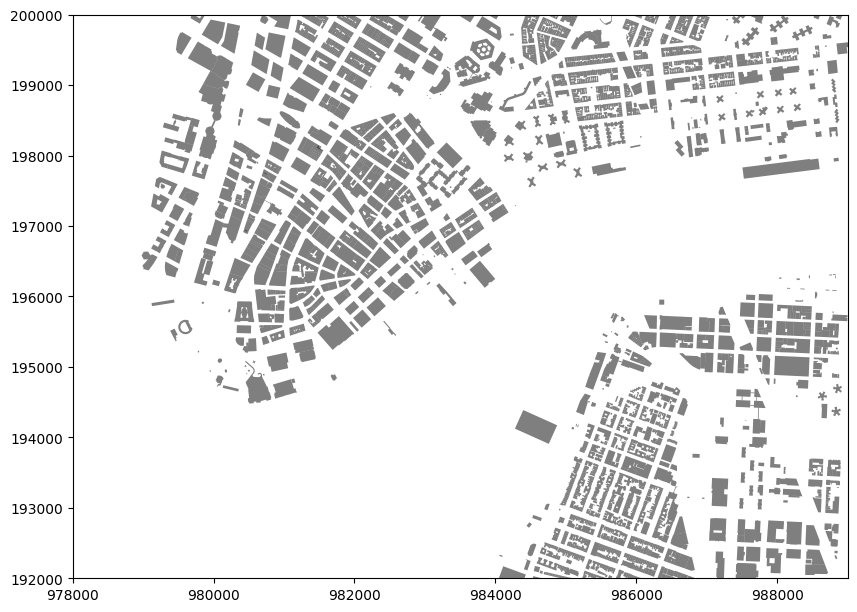

In [ ]:
ax = buildings_gdf.plot(
    facecolor="black",
    alpha=0.5,
    figsize=(10, 10),
)

In [15]:
# Load the tax lots dataset from the Shapefile
tax_lots_gdf = gpd.read_file(
    Path(DATA_DIRECTORY) / "nyc_mappluto_23v2_shp",
    bbox=bbox_gdf,
    use_arrow=True,
).to_crs(2263)

In [58]:
tax_lots_gdf.head(5)

,Borough,Block,Lot,CD,BCT2020,BCTCB2020,CT2010,CB2010,SchoolDist,Council,...,FIRM07_FLA,PFIRM15_FL,Version,DCPEdited,Latitude,Longitude,Notes,Shape_Leng,Shape_Area,geometry
0,MN,2,1,101,1000900,10009001022,9,1025,02,1,...,1,1,23v2,t,40.700369,-74.012911,None,0.0,100824.967451,"POLYGON ((980609.551 194220.421, 980608.726 19..."
1,MN,2,3,101,1000900,10009000001,9,0001,None,1,...,1,1,23v2,t,40.700781,-74.010913,None,0.0,4362.203252,"MULTIPOLYGON (((981176.547 194654.257, 981179...."
2,MN,3,1,101,1031900,10319001002,319,1001,02,1,...,1,1,23v2,t,40.702806,-74.015631,None,0.0,921410.335264,"MULTIPOLYGON (((980089.365 194658.743, 980083...."
3,MN,3,2,101,1000900,10009001018,9,1013,02,1,...,1,1,23v2,t,40.701780,-74.013633,None,0.0,14046.738976,"POLYGON ((980456.441 195042.573, 980458.399 19..."
4,MN,3,4,101,1031900,10319001000,319,1000,02,1,...,1,1,23v2,None,40.701255,-74.013939,None,0.0,2777.210233,"POLYGON ((980403.205 194731.754, 980401.324 19..."


In [60]:
tax_lots_gdf['area_from_geom'] = tax_lots_gdf['geometry'].area
tax_lots_gdf.head(5)

,Borough,Block,Lot,CD,BCT2020,BCTCB2020,CT2010,CB2010,SchoolDist,Council,...,PFIRM15_FL,Version,DCPEdited,Latitude,Longitude,Notes,Shape_Leng,Shape_Area,geometry,area_from_geom
0,MN,2,1,101,1000900,10009001022,9,1025,02,1,...,1,23v2,t,40.700369,-74.012911,None,0.0,100824.967451,"POLYGON ((980609.551 194220.421, 980608.726 19...",100824.968417
1,MN,2,3,101,1000900,10009000001,9,0001,None,1,...,1,23v2,t,40.700781,-74.010913,None,0.0,4362.203252,"MULTIPOLYGON (((981176.547 194654.257, 981179....",4362.203335
2,MN,3,1,101,1031900,10319001002,319,1001,02,1,...,1,23v2,t,40.702806,-74.015631,None,0.0,921410.335264,"MULTIPOLYGON (((980089.365 194658.743, 980083....",921410.338145
3,MN,3,2,101,1000900,10009001018,9,1013,02,1,...,1,23v2,t,40.701780,-74.013633,None,0.0,14046.738976,"POLYGON ((980456.441 195042.573, 980458.399 19...",14046.738746
4,MN,3,4,101,1031900,10319001000,319,1000,02,1,...,1,23v2,None,40.701255,-74.013939,None,0.0,2777.210233,"POLYGON ((980403.205 194731.754, 980401.324 19...",2777.210312


In [61]:
lot = tax_lots_gdf.head(1)

print("4326 (degrees):     ", lot.to_crs(4326).area.iloc[0]) # https://epsg.io/4326
print("3857 (web mercator):", lot.to_crs(3857).area.iloc[0], "sq m")  # https://epsg.io/3857
print("2263 (state plane): ", lot.to_crs(2263).area.iloc[0], "sq ft")  # https://epsg.io/2263
print("32618 (UTM 18N):    ", lot.to_crs(32618).area.iloc[0], "sq m")  # https://epsg.io/32618

4326 (degrees):      9.980611837326741e-07
3857 (web mercator): 16313.906150769675 sq m
2263 (state plane):  100824.96841721148 sq ft
32618 (UTM 18N):     9361.126042593765 sq m


/tmp/ipykernel_1372/3559838800.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print("4326 (degrees):     ", lot.to_crs(4326).area.iloc[0])


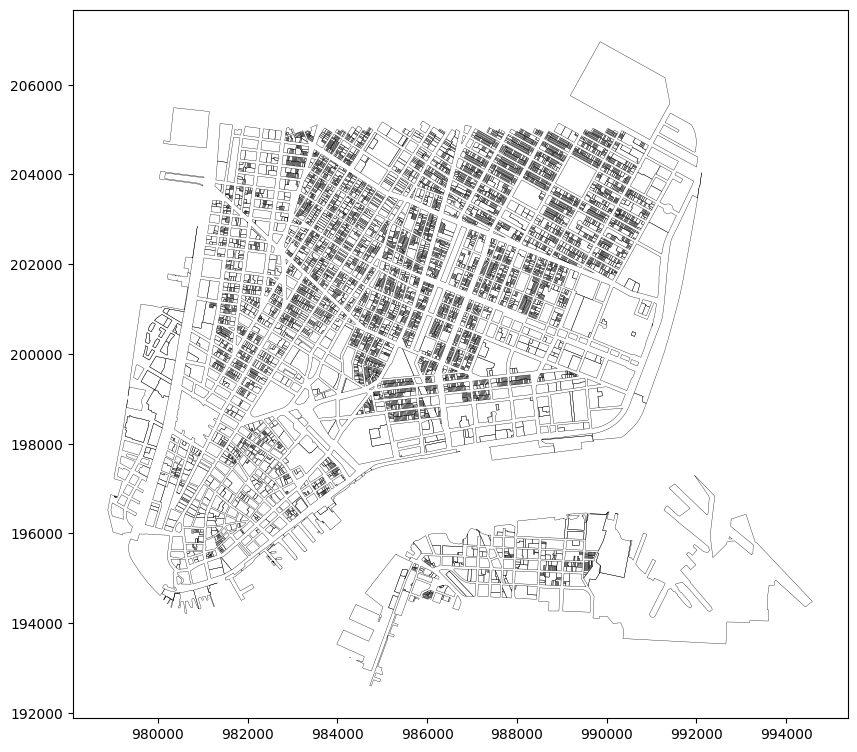

In [16]:
ax = tax_lots_gdf.plot(facecolor="none", lw=0.25, figsize=(10, 10))

In [17]:
# Convert the index column for the tax lots to a string
tax_lots_gdf["BBL"] = tax_lots_gdf["BBL"].astype(int).astype(str)

In [18]:
# Join the datat based on the borough, block, lot (BBL) identifier
joined_gdf = buildings_gdf.set_index("base_bbl").join(
    tax_lots_gdf.set_index("BBL"), rsuffix="_lots"
)

In [37]:
# For the spatial join, we need to use points to avoid duplicate intersections
# Create a copy of the buildings dataset
buildings_points_gdf = buildings_gdf.copy()
# Copy the original geometry to a new column just in case
buildings_points_gdf["footprint_geometry"] = buildings_points_gdf["geometry"]
# Use the centroid of the floorplate to set up the spatial join
buildings_points_gdf["geometry"] = buildings_points_gdf["geometry"].centroid

# Make the spatial join
sjoined_gdf = buildings_points_gdf.sjoin(
    tax_lots_gdf, predicate="intersects", how="left"
)

# Put the geometry back
sjoined_gdf["geometry"] = sjoined_gdf["footprint_geometry"]

# # Show which geometry was not joined
# ax = sjoined_gdf[sjoined_gdf["index_right"].isna()].plot(
#     facecolor="red", figsize=(10, 10)
# )
# tax_lots_gdf.plot(ax=ax, facecolor="grey", alpha=0.5, lw=0.25)

<Axes: >

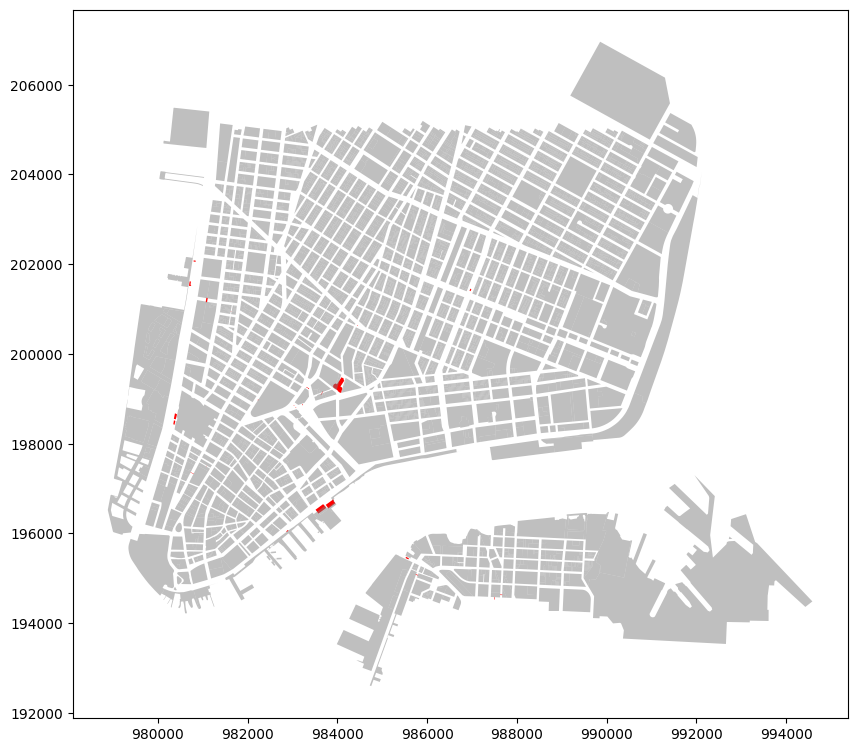

In [52]:
# 1. Find the buildings that didn't match any tax lot
not_joined = sjoined_gdf[sjoined_gdf["index_right"].isna()]
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
not_joined.plot(ax=ax, facecolor="red")
tax_lots_gdf.plot(ax=ax, facecolor="grey", alpha=0.5, lw=0.25)




<Axes: >

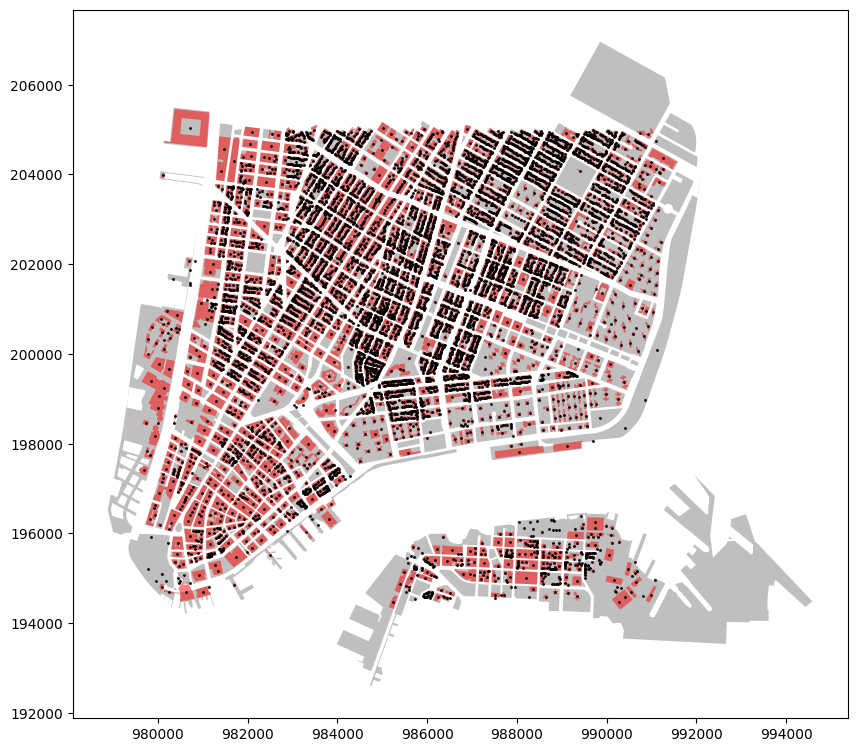

In [20]:
# Plot the centroid vs. the original data
ax = tax_lots_gdf.plot(facecolor="grey", alpha=0.5, figsize=(10, 10))
buildings_gdf.plot(ax=ax, facecolor="red", alpha=0.5, lw=0.25)
buildings_points_gdf.plot(ax=ax, color="black", markersize=1)

# Column Operations and Apply Functions


<Axes: >

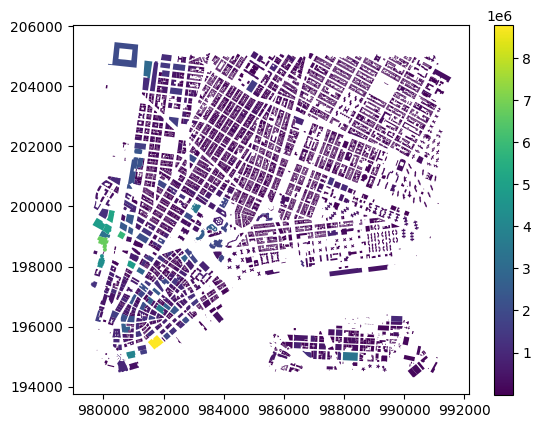

In [53]:
# Create a new column
buildings_gdf["gross_floor_area"] = (
    buildings_gdf.to_crs(2263).geometry.area * buildings_gdf["heightroof"] / 10
) # Assuming 10 feet per floor
buildings_gdf.plot(column="gross_floor_area", legend=True)

<Axes: >

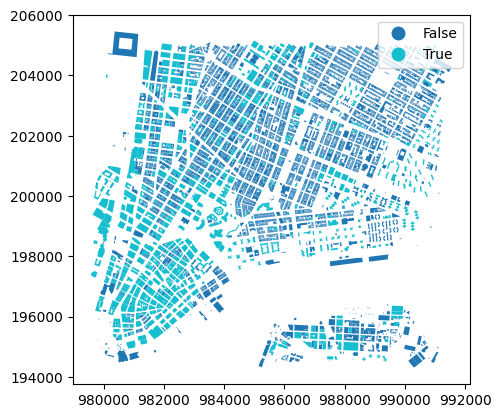

In [54]:
# Create a new column using apply()
buildings_gdf["taller_than_100"] = buildings_gdf.apply(
    lambda r: r["heightroof"] > 100, axis=1
)
buildings_gdf.plot(column="taller_than_100", legend=True)

<Axes: >

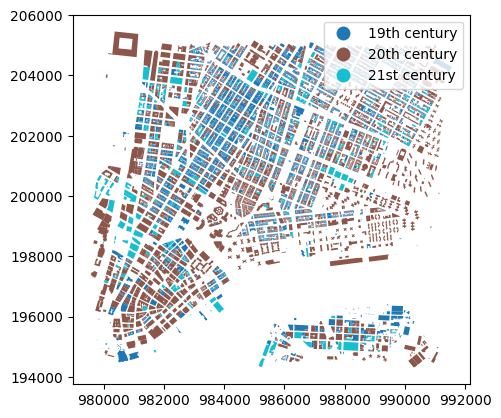

In [55]:
# Create a new column using apply() and a custom function
def classify_buildings(row):
    if row["cnstrct_yr"] > 2000:
        return "21st century"
    elif row["cnstrct_yr"] > 1900:
        return "20th century"
    else:
        return "19th century"


buildings_gdf["age"] = buildings_gdf.apply(classify_buildings, axis=1)
buildings_gdf.plot(column="age", legend=True)

# Writing to Rhino


In [24]:
# Install the Python module for working with Rhino files
# See more: https://mcneel.github.io/rhino3dm/python/api/index.html
!pip install rhino3dm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 46.1 MB/s eta 0:00:00


In [25]:
# Import the module now that you have it
import rhino3dm

In [26]:
# Creates a new file
new_3dm = rhino3dm.File3dm()
new_3dm.Settings.ModelUnitSystem = rhino3dm.UnitSystem.Feet

In [27]:
# Be sure to run this just once — otherwise you will add the layers multiple times
# Let's set a "constant" variable for red
RED_RGBA = (255, 0, 0, 255)
BLUE_RGBA = (0, 0, 255, 255)

# Add the layer with a name and color
new_3dm.Layers.AddLayer("Buildings", RED_RGBA)
new_3dm.Layers.AddLayer("Tax Lots", BLUE_RGBA)

1

In [28]:
# Let's define geometry attributes that we can re-use
bldg_attributes = rhino3dm.ObjectAttributes()
bldg_attributes.LayerIndex = 0

tax_lot_attributes = rhino3dm.ObjectAttributes()
tax_lot_attributes.LayerIndex = 1

In [29]:
# You can see which layers exist
for l in new_3dm.Layers:
    print(l.FullPath)

Buildings
Tax Lots


In [30]:
# Add the buildings
bldg_guids = []
for i, bldg in buildings_gdf.iterrows():
    polyline_pts = []
    for pt in bldg.geometry.exterior.coords:
        polyline_pts.append(rhino3dm.Point3d(pt[0], pt[1], 0))

    polyline = rhino3dm.Polyline(polyline_pts).ToPolylineCurve()
    guid = new_3dm.Objects.Add(polyline, bldg_attributes)
    bldg_guids.append(guid)

In [31]:
# Add the tax lots
tax_lot_guids = []
for i, tax_lot in tax_lots_gdf.iterrows():
    polyline_pts = []

    if tax_lot.geometry.geom_type == "MultiPolygon":
        for pt in tax_lot.geometry.geoms[0].exterior.coords:
            polyline_pts.append(rhino3dm.Point3d(pt[0], pt[1], 0))

    else:
        for pt in tax_lot.geometry.exterior.coords:
            polyline_pts.append(rhino3dm.Point3d(pt[0], pt[1], 0))

    polyline = rhino3dm.Polyline(polyline_pts).ToPolylineCurve()
    guid = new_3dm.Objects.Add(polyline, tax_lot_attributes)
    tax_lot_guids.append(guid)

In [32]:
# Save the file
# The second argument is the version number
new_3dm.Write("example_rhino_file.3dm", 7)

True

# Loading in Grasshopper with a CSV and GUIDs


In [33]:
# We can use Pandas to make a CSV (no geometry needed)
import pandas as pd

In [34]:
# Create basic dataframe
bldg_data_for_rhino_df = pd.DataFrame({"guid": bldg_guids})
# Join on the original index
bldg_data_for_rhino_df = bldg_data_for_rhino_df.join(joined_gdf.reset_index())

In [36]:
# Load this into Rhino to match the GUIDs
# We'll use the semicolon as the separator, as the data itself has commas
# We will also use index=False to avoid adding the extra index column
bldg_data_for_rhino_df = bldg_data_for_rhino_df.dropna(subset=["heightroof"])
bldg_data_for_rhino_df.to_csv("bldg_data_for_rhino.csv", sep=";", index=False)